## Setup

In [169]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo acadêmico
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ROOT = Path('.').resolve()
TESTCASE = 't01-ecn-sender-ect0-prague-fqcodel-ecn0'
CLIENT_LOG = ROOT / 'experiments' / TESTCASE / 'esp_client.log'
SERVER_LOG = ROOT / 'experiments' / TESTCASE / 'server.log'
OUTPUT_DIR = ROOT / 'experiments' / TESTCASE

# Criar diretório de saída se não existir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Client log: {CLIENT_LOG.exists()}")
print(f"Server log: {SERVER_LOG.exists()}")

Working directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague
Output directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t01-ecn-sender-ect0-prague-fqcodel-ecn0
Client log: False
Server log: False


## Parsing Cliente

In [170]:
def load_client_log(path=CLIENT_LOG):
    """Parse CSTATS format: CSTATS;t_ms;packets_sent;packets_received;inflight;rtt_us;jitter_us;packet_window;packet_burst;pacing_rate_bps
    Note: RTT and Jitter are in microseconds (us), converted to milliseconds (ms)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('CSTATS;'):
                continue
            parts = line.split(';')
            if len(parts) != 10:
                continue
            try:
                rows.append({
                    't_ms': int(parts[1]),
                    'packets_sent': int(parts[2]),
                    'packets_received': int(parts[3]),
                    'inflight': int(parts[4]),
                    'rtt_ms': float(parts[5]) / 1000.0,  # Convert microseconds to milliseconds
                    'jitter_ms': float(parts[6]) / 1000.0,  # Convert microseconds to milliseconds
                    'packet_window': int(parts[7]),
                    'packet_burst': int(parts[8]),
                    'pacing_rate_bps': float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['t_client_s'] = df['t_ms'] / 1000.0
        df = df.sort_values('t_client_s').reset_index(drop=True)
        print(f"\n✓ Cliente: {len(df)} amostras")
        print(f"  Tempo: [{df['t_client_s'].min():.3f}, {df['t_client_s'].max():.3f}] s")
        print(f"  Pacotes enviados: {df['packets_sent'].iloc[-1]} (total)")
        print(f"  RTT: {df['rtt_ms'].mean():.2f} ± {df['rtt_ms'].std():.2f} ms")
        print(f"  Jitter: {df['jitter_ms'].mean():.2f} ± {df['jitter_ms'].std():.2f} ms")
        print(f"  Pacing: {df['pacing_rate_bps'].mean()/1e6:.2f} ± {df['pacing_rate_bps'].std()/1e6:.2f} Mbps")
    return df

try:
    df_client = load_client_log()
    display(df_client.head())
except FileNotFoundError:
    print(f"✗ Cliente não encontrado: {CLIENT_LOG}")
    df_client = pd.DataFrame()

✗ Cliente não encontrado: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t01-ecn-sender-ect0-prague-fqcodel-ecn0/esp_client.log


## Parsing Servidor

In [171]:

# ===== SERVER LOG PARSER (auto-detect format) =====
# Supports two formats:
#   1) RECVER bucket format: "[RECVER]: 8.09 sec, Rcvd: 1396000 B/s, ..."
#   2) Verbose per-packet format: "r: time, timestamp, ... / s: time, timestamp, ..."

# Regex for RECVER bucket format
server_re = re.compile(
    r'\[RECVER\]:\s+'
    r'(?P<time_sec>[\d.]+)\s+sec,\s+'
    r'Rcvd:\s+(?P<rcvd>[\d.]+)\s+B/s,\s+'
    r'Sent:\s+(?P<sent>[\d.]+)\s+B/s,\s+'
    r'(?:RTT:\s+(?P<rtt>N/A|[\d.]+\s+ms)|ATO:\s+(?P<ato>[\d.]+)\s+ms),\s+'
    r'Mark:\s+(?P<mark_pct>[\d.]+)%\((?P<ce>\d+)/(?P<mark_total>\d+)\),\s+'
    r'Lost:\s+(?P<lost_pct>[\d.]+)%\((?P<lost>\d+)/(?P<lost_total>\d+)\)'
)

def _detect_server_format(path):
    """Peek at the file to detect RECVER vs verbose format."""
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('[RECVER]'):
                return 'recver'
            if line.startswith('r:') or line.startswith('s:'):
                return 'verbose'
    return 'unknown'

def _parse_verbose_server_log(path, bucket_ms=200):
    """Parse verbose per-packet format and aggregate into time buckets."""
    send_rows = []  # 's:' lines contain the feedback counters
    recv_rows = []  # 'r:' lines contain received packet info
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('s:') and not line.startswith('s: time'):
                # s: time, timestamp, echoed_timestamp, time_diff, seqnr, packet_size, pkts_received, pkts_CE, pkts_lost, error_L4S
                parts = line[3:].split(',')
                if len(parts) >= 10:
                    try:
                        send_rows.append({
                            'time_us': int(parts[0].strip()),
                            'seqnr': int(parts[4].strip()),
                            'packet_size': int(parts[5].strip()),
                            'pkts_received': int(parts[6].strip()),
                            'pkts_CE': int(parts[7].strip()),
                            'pkts_lost': int(parts[8].strip()),
                            'error_L4S': int(parts[9].strip()),
                        })
                    except (ValueError, IndexError):
                        continue
            elif line.startswith('r:') and not line.startswith('r: time'):
                # r: time, timestamp, echoed_timestamp, time_diff, seqnr, bytes_received
                parts = line[3:].split(',')
                if len(parts) >= 6:
                    try:
                        recv_rows.append({
                            'time_us': int(parts[0].strip()),
                            'seqnr': int(parts[4].strip()),
                            'bytes_received': int(parts[5].strip()),
                        })
                    except (ValueError, IndexError):
                        continue

    if not send_rows:
        print("⚠️  No 's:' lines found in verbose server log")
        return pd.DataFrame()

    df_s = pd.DataFrame(send_rows)
    df_s['time_sec'] = df_s['time_us'] / 1e6

    # Aggregate into time buckets (like RECVER format)
    bucket_sec = bucket_ms / 1000.0
    df_s['bucket'] = (df_s['time_sec'] / bucket_sec).astype(int) * bucket_sec

    agg = df_s.groupby('bucket').agg(
        pkts_in_bucket=('seqnr', 'count'),
        pkts_received_max=('pkts_received', 'max'),
        pkts_received_min=('pkts_received', 'min'),
        pkts_CE_max=('pkts_CE', 'max'),
        pkts_CE_min=('pkts_CE', 'min'),
        pkts_lost_max=('pkts_lost', 'max'),
        pkts_lost_min=('pkts_lost', 'min'),
        bytes_total=('packet_size', 'sum'),
    ).reset_index()

    # Compute increments per bucket (counters are cumulative)
    agg['ce_count'] = agg['pkts_CE_max'] - agg['pkts_CE_min']
    agg['ce_total'] = agg['pkts_received_max'] - agg['pkts_received_min']
    # If bucket has only 1 packet, use the pkts_in_bucket as total
    agg.loc[agg['ce_total'] == 0, 'ce_total'] = agg.loc[agg['ce_total'] == 0, 'pkts_in_bucket']
    agg['loss_count'] = agg['pkts_lost_max'] - agg['pkts_lost_min']
    agg['loss_total'] = agg['ce_total']

    # Compute rates
    agg['time_sec'] = agg['bucket']
    # FIX: throughput must come from 'r:' lines (data packets, bytes_received),
    # not from 's:' lines whose packet_size is the 26-byte ACK.
    if recv_rows:
        df_r = pd.DataFrame(recv_rows)
        # FIX: server log may contain duplicated 'r:' lines (~3x); dedupe by seqnr
        df_r = df_r.drop_duplicates(subset='seqnr', keep='first')
        df_r['time_sec'] = df_r['time_us'] / 1e6
        df_r['bucket'] = (df_r['time_sec'] / bucket_sec).astype(int) * bucket_sec
        rx = df_r.groupby('bucket')['bytes_received'].sum().rename('rx_bytes')
        agg = agg.merge(rx, on='bucket', how='left')
        agg['rx_bytes'] = agg['rx_bytes'].fillna(0)
        agg['rcvd_rate_bytes_s'] = agg['rx_bytes'] / bucket_sec
    else:
        agg['rcvd_rate_bytes_s'] = agg['bytes_total'] / bucket_sec
    agg['sent_rate_bytes_s'] = 0  # not meaningful in server verbose log
    agg['ce_rate_percent'] = np.where(agg['ce_total'] > 0, agg['ce_count'] / agg['ce_total'] * 100, 0.0)
    agg['loss_rate_percent'] = np.where(agg['loss_total'] > 0, agg['loss_count'] / agg['loss_total'] * 100, 0.0)
    agg['loss_rate_percent'] = agg['loss_rate_percent'].clip(0, 100)

    cols = ['time_sec', 'rcvd_rate_bytes_s', 'sent_rate_bytes_s',
            'ce_rate_percent', 'ce_count', 'ce_total',
            'loss_rate_percent', 'loss_count', 'loss_total']
    return agg[cols].sort_values('time_sec').reset_index(drop=True)

def _parse_recver_server_log(path):
    """Parse RECVER bucket format."""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            m = server_re.match(line.strip())
            if not m:
                continue
            g = m.groupdict()
            try:
                rows.append({
                    'time_sec': float(g['time_sec']),
                    'rcvd_rate_bytes_s': float(g['rcvd']),
                    'sent_rate_bytes_s': float(g['sent']),
                    'ce_rate_percent': float(g['mark_pct']),
                    'ce_count': int(g['ce']),
                    'ce_total': int(g['mark_total']),
                    'loss_rate_percent': float(g['lost_pct']),
                    'loss_count': int(g['lost']),
                    'loss_total': int(g['lost_total']),
                })
            except (ValueError, KeyError):
                continue
    df = pd.DataFrame(rows)
    if not df.empty:
        df['loss_rate_percent'] = df['loss_rate_percent'].clip(0, 100)
        df = df.sort_values('time_sec').reset_index(drop=True)
    return df

def load_server_log(path=SERVER_LOG):
    """Auto-detect and parse server log (RECVER or verbose format)."""
    fmt = _detect_server_format(path)
    print(f"  Server log format detected: {fmt}")

    if fmt == 'recver':
        df = _parse_recver_server_log(path)
    elif fmt == 'verbose':
        df = _parse_verbose_server_log(path)
    else:
        print(f"⚠️  Unknown server log format in {path}")
        return pd.DataFrame()

    if not df.empty:
        print(f"\n✓ Servidor: {len(df)} amostras")
        print(f"  Formato: {fmt}")
        print(f"  Tempo: [{df['time_sec'].min():.3f}, {df['time_sec'].max():.3f}] s")
        print(f"  RX throughput: {df['rcvd_rate_bytes_s'].mean():.0f} ± {df['rcvd_rate_bytes_s'].std():.0f} B/s")
        print(f"  CE-mark rate: {df['ce_rate_percent'].mean():.2f} ± {df['ce_rate_percent'].std():.2f} %")
        print(f"  Loss rate: {df['loss_rate_percent'].mean():.4f} ± {df['loss_rate_percent'].std():.4f} %")
    else:
        print(f"⚠️  No data parsed from server log")
    return df

try:
    df_server = load_server_log()
    if not df_server.empty:
        display(df_server.head())
except FileNotFoundError:
    print(f"✗ Servidor não encontrado: {SERVER_LOG}")
    df_server = pd.DataFrame()


✗ Servidor não encontrado: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t01-ecn-sender-ect0-prague-fqcodel-ecn0/server.log


## Metadados do Teste

In [172]:
def extract_metadata(path=CLIENT_LOG):
    """Extract test metadata from client log header"""
    meta = {}
    try:
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('IoT Node ID:'):
                    meta['IoT Node ID'] = line.split(':', 1)[1].strip()
                elif line.startswith('Test Scenario:'):
                    meta['Test Scenario'] = line.split(':', 1)[1].strip()
                elif line.startswith('Payload Size:'):
                    meta['Payload Size'] = line.split(':', 1)[1].strip()
                elif line.startswith('Initial Burst Limit:'):
                    meta['Initial Burst Limit'] = line.split(':', 1)[1].strip()
                elif line.startswith('Duration:'):
                    meta['Duration'] = line.split(':', 1)[1].strip()
                elif line.startswith('ECN'):
                    meta['ECN'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway CC Algorithm:'):
                    meta['Gateway CC Algorithm'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway Qdisc:'):
                    meta['Gateway Qdisc'] = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        pass
    return meta

metadata = extract_metadata()
print("\n📋 Test Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


📋 Test Metadata:


## Compute Goodput (RX / Pacing)

In [173]:
# Prepare goodput metric (cliente only)
if not df_client.empty:
    # Convert pacing_rate_bps to Mbps for goodput calculation
    df_client['pacing_rate_mbps'] = df_client['pacing_rate_bps'] / 1e6
    
    # Goodput = RX / Pacing (both in Mbps)
    # But we don't have RX from client directly, so goodput will be estimated differently
    # For now, mark it as NA
    print(f"✓ Cliente prepared: {len(df_client)} rows")
else:
    print("✗ Client data unavailable")

✗ Client data unavailable


## 📊 Análise de Transmissão (Cliente ↔ Servidor)

In [174]:

# Análise Comparativa: Cliente (TX) vs Servidor (RX)
# Handles both full-coverage and partial-coverage server data

transmission_stats = {}

if not df_client.empty:
    # === CLIENT STATS (always available) ===
    client_packets_sent = df_client['packets_sent'].iloc[-1]
    client_duration_s = df_client['t_client_s'].max() - df_client['t_client_s'].min()

    # Extract packet size from metadata
    PACKET_SIZE_BYTES = 1396  # Default
    if 'Payload Size' in metadata:
        match = re.search(r'(\d+)\s*bytes', metadata['Payload Size'])
        if match:
            PACKET_SIZE_BYTES = int(match.group(1))

    client_bytes_sent = client_packets_sent * PACKET_SIZE_BYTES

    print("="*70)
    print("📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor")
    print("="*70)

    if not df_server.empty:
        # === SERVER COVERAGE CHECK ===
        server_duration_s = df_server['time_sec'].max() - df_server['time_sec'].min()
        coverage_pct = (server_duration_s / client_duration_s * 100) if client_duration_s > 0 else 0

        # Server packets: sum of per-bucket totals
        server_packets_received = df_server['ce_total'].sum()
        server_packets_marked = df_server['ce_count'].sum()
        server_packets_lost = df_server['loss_count'].sum()

        packets_lost_total = client_packets_sent - server_packets_received
        packet_loss_rate = (packets_lost_total / client_packets_sent * 100) if client_packets_sent > 0 else 0

        server_bytes_received = server_packets_received * PACKET_SIZE_BYTES
        bytes_lost = client_bytes_sent - server_bytes_received
        byte_loss_rate = (bytes_lost / client_bytes_sent * 100) if client_bytes_sent > 0 else 0

        # Coverage warning
        if coverage_pct < 90:
            print(f"\n⚠️  SERVER COVERAGE WARNING: {coverage_pct:.1f}%")
            print(f"   Server captured {server_duration_s:.1f}s of {client_duration_s:.1f}s test")
            print(f"   Server saw {server_packets_received:,} of {client_packets_sent:,} packets ({server_packets_received/client_packets_sent*100:.1f}%)")
            print(f"   ➜ Likely cause: running server with -v (verbose) flag causes I/O backpressure")
            print(f"   ➜ Fix: re-run server WITHOUT -v flag to get full [RECVER] bucket coverage\n")

        print(f"\n{'Métrica':<40} {'Cliente (TX)':<15} {'Servidor (RX)':<15} {'Delta':<15}")
        print("-"*70)
        print(f"{'Duração (s)':<40} {client_duration_s:<15.1f} {server_duration_s:<15.1f} {'':>15}")
        print(f"{'Cobertura do servidor':<40} {'':<15} {coverage_pct:<14.1f}% {'':<15}")
        print(f"{'Pacotes':<40} {client_packets_sent:<15,} {server_packets_received:<15,} {packets_lost_total:<15,}")
        print(f"{'Taxa de perda de pacotes':<40} {'':<15} {'':<15} {packet_loss_rate:>14.2f}%")
        print(f"{'Bytes ({PACKET_SIZE_BYTES} B/pkt)':<40} {client_bytes_sent:<15,} {int(server_bytes_received):<15,} {int(bytes_lost):<15,}")
        print(f"{'Taxa de perda de bytes':<40} {'':<15} {'':<15} {byte_loss_rate:>14.2f}%")
        print("-"*70)
        print(f"\nℹ️  Pacotes com CE-mark: {server_packets_marked:,}")
        print(f"ℹ️  Taxa de marcação ECN: {(server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0:.2f}%")
        if server_packets_lost > 0:
            print(f"ℹ️  Pacotes perdidos (servidor): {server_packets_lost:,}")

        transmission_stats = {
            'packet_size_bytes': PACKET_SIZE_BYTES,
            'client_packets_sent': client_packets_sent,
            'client_duration_s': client_duration_s,
            'server_packets_received': server_packets_received,
            'server_packets_marked': server_packets_marked,
            'server_duration_s': server_duration_s,
            'server_coverage_pct': coverage_pct,
            'packets_lost': packets_lost_total,
            'packet_loss_rate_percent': packet_loss_rate,
            'ecn_mark_rate_percent': (server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0,
            'client_bytes_sent_est': client_bytes_sent,
            'server_bytes_received_est': int(server_bytes_received),
            'bytes_lost_est': int(bytes_lost),
            'byte_loss_rate_percent': byte_loss_rate,
        }
    else:
        print("\n⚠️  Servidor: sem dados. Análise apenas do cliente.")
        print(f"\n{'Métrica':<40} {'Cliente (TX)':<15}")
        print("-"*55)
        print(f"{'Duração (s)':<40} {client_duration_s:<15.1f}")
        print(f"{'Pacotes enviados':<40} {client_packets_sent:<15,}")
        print(f"{'Bytes enviados ({PACKET_SIZE_BYTES} B/pkt)':<40} {client_bytes_sent:<15,}")

        transmission_stats = {
            'packet_size_bytes': PACKET_SIZE_BYTES,
            'client_packets_sent': client_packets_sent,
            'client_duration_s': client_duration_s,
            'client_bytes_sent_est': client_bytes_sent,
            'server_coverage_pct': 0,
        }
else:
    print("⚠️  Dados do cliente indisponíveis")


⚠️  Dados do cliente indisponíveis


In [175]:

# Gráfico de Transmissão: Cliente → Servidor
if not df_client.empty and not df_server.empty and transmission_stats:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Transmission Analysis: Client → Server', fontsize=13, fontweight='bold')
    
    # (H) Packets: Sent vs Received
    ax = axes[0]
    categories = ['Sent', 'Received', 'Lost']
    values = [
        transmission_stats['client_packets_sent'],
        transmission_stats['server_packets_received'],
        transmission_stats['packets_lost']
    ]
    colors = ['#06A77D', '#1E88E5', '#D32F2F']
    
    bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Packets', fontsize=10)
    ax.set_title('(H) Packet Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # (I) Bytes: Sent vs Received
    ax = axes[1]
    categories = ['Sent', 'Received', 'Lost']
    bytes_values = [
        transmission_stats['client_bytes_sent_est'],
        transmission_stats['server_bytes_received_est'],
        transmission_stats['bytes_lost_est']
    ]
    
    bars = ax.bar(categories, bytes_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars (in bytes)
    for bar, val in zip(bars, bytes_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Bytes', fontsize=10)
    ax.set_title('(I) Byte Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save the transmission plot
    fname = OUTPUT_DIR / f"{base_name}_transmission_analysis.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()


## Plotting Functions

In [176]:
def plot_client_metrics(df_client, metadata):
    """Plot RTT, Jitter, Inflight, Pacing Rate"""
    if df_client.empty:
        print("No client data to plot")
        return
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    fig.suptitle('Client Metrics (ESP32 - UDP-Prague)', fontsize=13, fontweight='bold')
    
    # (A) RTT
    ax = axes[0]
    ax.plot(df_client['t_client_s'], df_client['rtt_ms'], color='#2E86AB', linewidth=1.5, label='RTT')
    ax.set_ylabel('RTT (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(A) Round Trip Time', fontsize=10)
    
    # (B) Jitter
    ax = axes[1]
    ax.plot(df_client['t_client_s'], df_client['jitter_ms'], color='#A23B72', linewidth=1.5, label='Jitter')
    ax.set_ylabel('Jitter (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(B) Jitter (Stability)', fontsize=10)
    
    # (C) Inflight
    ax = axes[2]
    ax.plot(df_client['t_client_s'], df_client['inflight'], color='#F18F01', linewidth=1.5, label='Inflight')
    ax.set_ylabel('Inflight (packets)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(C) In-Flight Packets (CC Behavior)', fontsize=10)
    
    # (D) Pacing Rate
    ax = axes[3]
    ax.plot(df_client['t_client_s'], df_client['pacing_rate_mbps'], color='#06A77D', linewidth=1.5, label='Pacing Rate')
    ax.set_ylabel('Pacing Rate (Mbps)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(D) Pacing Rate (Adaptation)', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_server_metrics(df_server, metadata):
    """Plot RX Throughput, CE-mark Rate, Loss Rate"""
    if df_server.empty:
        print("No server data to plot")
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    fig.suptitle('Server Metrics (DualPI2 Gateway)', fontsize=13, fontweight='bold')
    
    # (E) RX Throughput
    ax = axes[0]
    ax.plot(df_server['time_sec'], df_server['rcvd_rate_bytes_s'], color='#1E88E5', linewidth=1.5, label='RX Throughput')
    ax.set_ylabel('Throughput (bytes/s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(E) Received Throughput', fontsize=10)
    
    # (F) CE-mark Rate
    ax = axes[1]
    ax.plot(df_server['time_sec'], df_server['ce_rate_percent'], color='#D32F2F', linewidth=1.5, label='CE-mark Rate')
    ax.set_ylabel('CE-mark Rate (%)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(F) CE-Mark Rate (L4S Signal)', fontsize=10)
    
    # (G) Loss Rate
    ax = axes[2]
    ax.plot(df_server['time_sec'], df_server['loss_rate_percent'], color='#FF6F00', linewidth=1.5, label='Loss Rate')
    ax.set_ylabel('Loss Rate (%)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(G) Packet Loss', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_cdf_rtt(df_client):
    """Plot CDF of RTT"""
    if df_client.empty:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rtt_sorted = np.sort(df_client['rtt_ms'].dropna())
    cdf = np.arange(1, len(rtt_sorted) + 1) / len(rtt_sorted)
    
    ax.plot(rtt_sorted, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF')
    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Probability (%)', fontsize=11)
    ax.set_title('(I) CDF of RTT (Client)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig

print("✓ Plotting functions defined")

✓ Plotting functions defined


## Generate and Save Plots

In [177]:
# Generate output filename from metadata
def build_output_name(metadata):
    parts = ['prague_academic']
    
    scenario = metadata.get('Test Scenario', '').lower().replace(' ', '_')
    if scenario:
        parts.append(scenario)
    
    node = metadata.get('IoT Node ID', '')
    if node:
        digits = re.findall(r'\d+', node)
        if digits:
            parts.append(f'node{digits[0]}')
    
    cc = metadata.get('Gateway CC Algorithm', '').lower().replace(' ', '_')
    if cc:
        parts.append(f'cc{cc}')
    
    qdisc = metadata.get('Gateway Qdisc', '').lower().replace(' ', '_')
    if qdisc:
        parts.append(f'qdisc{qdisc}')
    
    ecn = metadata.get('ECN', '')
    if ecn:
        parts.append(f'ecn{ecn}')

    return '_'.join(parts)

base_name = build_output_name(metadata)
print(f"Output name: {base_name}")

# Plot and save client metrics
if not df_client.empty:
    fig = plot_client_metrics(df_client, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_client_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save server metrics
if not df_server.empty:
    fig = plot_server_metrics(df_server, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_server_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save CDF of RTT
if not df_client.empty:
    fig = plot_cdf_rtt(df_client)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_rtt_cdf.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

Output name: prague_academic


## Export CSV

In [178]:

# Export raw data
if not df_client.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_client.csv"
    df_client.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

if not df_server.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_server.csv"
    df_server.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

# Summary statistics with confidence intervals
if not df_client.empty or not df_server.empty:
    from scipy.stats import t as t_dist

    def _ci(data, confidence=0.95):
        n = len(data)
        if n < 2:
            return np.nan, np.nan
        se = np.std(data, ddof=1) / np.sqrt(n)
        h = se * t_dist.ppf((1 + confidence) / 2, n - 1)
        return np.mean(data) - h, np.mean(data) + h

    summary = {}
    if not df_client.empty:
        # Steady-state (exclude first 10%)
        n_warmup = int(len(df_client) * 0.10)
        df_ss = df_client.iloc[n_warmup:]

        rtt_ci = _ci(df_ss['rtt_ms'])
        jit_ci = _ci(df_ss['jitter_ms'])

        summary.update({
            'client_samples': len(df_client),
            'steadystate_samples': len(df_ss),
            'client_duration_s': df_client['t_client_s'].max() - df_client['t_client_s'].min(),
            'rtt_mean_ms': df_ss['rtt_ms'].mean(),
            'rtt_ci_lower_ms': rtt_ci[0],
            'rtt_ci_upper_ms': rtt_ci[1],
            'rtt_p50_ms': df_ss['rtt_ms'].median(),
            'rtt_p95_ms': df_ss['rtt_ms'].quantile(0.95),
            'rtt_p99_ms': df_ss['rtt_ms'].quantile(0.99),
            'rtt_cv_pct': (df_ss['rtt_ms'].std() / df_ss['rtt_ms'].mean() * 100) if df_ss['rtt_ms'].mean() != 0 else np.nan,
            'jitter_mean_ms': df_ss['jitter_ms'].mean(),
            'jitter_ci_lower_ms': jit_ci[0],
            'jitter_ci_upper_ms': jit_ci[1],
            'inflight_mean': df_ss['inflight'].mean(),
            'pacing_rate_mean_mbps': df_ss['pacing_rate_mbps'].mean(),
        })

    if not df_server.empty:
        summary.update({
            'server_samples': len(df_server),
            'server_duration_s': df_server['time_sec'].max() - df_server['time_sec'].min(),
            'rx_throughput_mean_bytes_s': df_server['rcvd_rate_bytes_s'].mean(),
            'rx_throughput_min_bytes_s': df_server['rcvd_rate_bytes_s'].min(),
            'rx_throughput_max_bytes_s': df_server['rcvd_rate_bytes_s'].max(),
            'ce_mark_rate_mean_percent': df_server['ce_rate_percent'].mean(),
            'loss_rate_mean_percent': df_server['loss_rate_percent'].mean(),
        })

    # Add transmission analysis stats
    if transmission_stats:
        summary.update(transmission_stats)

    summary_df = pd.DataFrame([summary])
    fname_summary = OUTPUT_DIR / f"{base_name}_summary.csv"
    summary_df.to_csv(fname_summary, index=False)
    print(f"✓ Saved: {fname_summary}")
    print(f"\n📊 Summary Statistics:")
    print(summary_df.T)


## 📐 Statistical Rigor (Academic)

In [179]:

# ===== STATISTICAL RIGOR FOR ACADEMIC PUBLICATION =====
# Implements: 95% CI, Shapiro-Wilk normality, CV, box plots,
# annotated CDF, steady-state segmentation.

from scipy.stats import shapiro, t as t_dist

def compute_ci(data, confidence=0.95):
    """Compute confidence interval using t-distribution."""
    n = len(data)
    if n < 2:
        return np.nan, np.nan, np.nan
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * t_dist.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h

def compute_cv(data):
    """Coefficient of variation (%)."""
    mean = np.mean(data)
    if mean == 0:
        return np.nan
    return (np.std(data, ddof=1) / mean) * 100

if not df_client.empty:
    # --- Steady-state segmentation ---
    warmup_frac = 0.10  # exclude first 10%
    n_total = len(df_client)
    n_warmup = int(n_total * warmup_frac)
    df_ss = df_client.iloc[n_warmup:].copy()

    print("="*70)
    print("📐 STATISTICAL RIGOR REPORT")
    print("="*70)
    print(f"\nTotal samples: {n_total:,}")
    print(f"Warmup excluded: first {n_warmup:,} samples ({warmup_frac*100:.0f}%)")
    print(f"Steady-state samples: {len(df_ss):,}")

    # --- 95% Confidence Intervals ---
    metrics = {
        'RTT (ms)': df_ss['rtt_ms'].values,
        'Jitter (ms)': df_ss['jitter_ms'].values,
        'Inflight (pkts)': df_ss['inflight'].values,
        'Pacing Rate (Mbps)': df_ss['pacing_rate_mbps'].values,
    }

    print(f"\n{'Metric':<25} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14} {'CV (%)':>10} {'Normality':>12}")
    print("-"*85)

    stat_results = {}
    for name, data in metrics.items():
        mean, ci_lo, ci_hi = compute_ci(data)
        cv = compute_cv(data)

        # Shapiro-Wilk (sample up to 5000 for performance)
        sample = data[:5000] if len(data) > 5000 else data
        if len(sample) >= 20:
            sw_stat, sw_p = shapiro(sample)
            normality = f"p={sw_p:.2e}"
        else:
            sw_stat, sw_p = np.nan, np.nan
            normality = "N/A (n<20)"

        print(f"{name:<25} {mean:>10.3f} [{ci_lo:>13.3f}, {ci_hi:>13.3f}] {cv:>9.1f}%  {normality}")

        stat_results[name] = {
            'mean': mean, 'ci_lower': ci_lo, 'ci_upper': ci_hi,
            'cv': cv, 'shapiro_p': sw_p, 'n': len(data),
        }

    # --- Box Plots (steady-state) ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle('Steady-State Distribution (warmup excluded)', fontsize=13, fontweight='bold')

    for ax, (name, data) in zip(axes, metrics.items()):
        bp = ax.boxplot(data, patch_artist=True,
                        boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
        mean_val, ci_lo, ci_hi = compute_ci(data)
        ax.axhline(mean_val, color='green', linestyle='--', alpha=0.7, label=f'Mean={mean_val:.2f}')
        ax.axhspan(ci_lo, ci_hi, color='green', alpha=0.1, label='95% CI')
        ax.set_title(name, fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = OUTPUT_DIR / f"{base_name}_boxplots_steadystate.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {fname}")
    plt.show()

    # --- Annotated CDF ---
    fig, ax = plt.subplots(figsize=(10, 6))
    rtt_ss = np.sort(df_ss['rtt_ms'].dropna().values)
    cdf = np.arange(1, len(rtt_ss) + 1) / len(rtt_ss)

    ax.plot(rtt_ss, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF (steady-state)')

    # Annotate percentiles
    for pct, color, style in [(50, '#06A77D', '--'), (95, '#F18F01', '--'), (99, '#D32F2F', ':')]:
        val = np.percentile(rtt_ss, pct)
        ax.axvline(val, color=color, linestyle=style, alpha=0.7)
        ax.axhline(pct, color=color, linestyle=style, alpha=0.3)
        ax.annotate(f'P{pct}={val:.2f}ms', xy=(val, pct), fontsize=9,
                    xytext=(10, -15), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color=color), color=color)

    # Annotate mean with CI
    rtt_mean, rtt_ci_lo, rtt_ci_hi = compute_ci(rtt_ss)
    ax.axvspan(rtt_ci_lo, rtt_ci_hi, color='green', alpha=0.1, label=f'95% CI [{rtt_ci_lo:.2f}, {rtt_ci_hi:.2f}]')

    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Cumulative Probability (%)', fontsize=11)
    ax.set_title('CDF of RTT — Steady State (warmup excluded)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = OUTPUT_DIR / f"{base_name}_rtt_cdf_annotated.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()

    # --- Summary for dissertation ---
    print("\n" + "="*70)
    print("📝 SUMMARY FOR DISSERTATION")
    print("="*70)
    r = stat_results.get('RTT (ms)', {})
    j = stat_results.get('Jitter (ms)', {})
    print(f"\nTest: {TESTCASE}")
    print(f"Steady-state samples: {len(df_ss):,} ({(1-warmup_frac)*100:.0f}% of {n_total:,})")
    if r:
        print(f"RTT: {r['mean']:.3f} ms [95% CI: {r['ci_lower']:.3f}, {r['ci_upper']:.3f}], CV={r['cv']:.1f}%")
    if j:
        print(f"Jitter: {j['mean']:.3f} ms [95% CI: {j['ci_lower']:.3f}, {j['ci_upper']:.3f}], CV={j['cv']:.1f}%")
    print(f"RTT P50={df_ss['rtt_ms'].median():.3f} ms, P95={df_ss['rtt_ms'].quantile(0.95):.3f} ms, P99={df_ss['rtt_ms'].quantile(0.99):.3f} ms")

    if not df_server.empty:
        coverage = transmission_stats.get('server_coverage_pct', 0)
        if coverage < 90:
            print(f"\n⚠️  Server coverage: {coverage:.1f}% — server metrics may not be representative")
else:
    print("⚠️  No client data available for statistical analysis")


⚠️  No client data available for statistical analysis


## Batch Processing: All Scenarios (Multi-Run Support)

Processes all experiment directories with client logs.
For each scenario with N runs:

1. **Individual**: Stats, plots, and CSV per run
2. **Aggregated**: Mean of means, inter-run CI, run-to-run comparison
3. **Cross-scenario**: Mann-Whitney U uses aggregated data (Cell 24)

Supports both `esp_client.log` (legacy) and `esp_client_N.log` (multi-run).

In [180]:
# ===== BATCH PROCESSING: ALL SCENARIOS (MULTI-RUN) =====
# Processes each run individually, then aggregates across runs per scenario.
# Reuses functions from Cells 3, 5, 7, 14, 16, 20 (must run those first).

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

EXPERIMENTS_DIR = ROOT / 'experiments'
WARMUP_FRAC = 0.10

# --- Discovery functions ---
def find_client_logs(exp_dir):
    """Find client logs: esp_client_1.log, _2.log, ... or esp_client.log (legacy)."""
    logs = sorted(exp_dir.glob('esp_client_[0-9]*.log'))
    if not logs:
        legacy = exp_dir / 'esp_client.log'
        if legacy.exists():
            logs = [legacy]
    return logs

def find_server_logs(exp_dir):
    """Find server logs: server_1.log, _2.log, ... or server.log (legacy)."""
    logs = sorted(exp_dir.glob('server_[0-9]*.log'))
    if not logs:
        legacy = exp_dir / 'server.log'
        if legacy.exists():
            logs = [legacy]
    return logs

def run_label(log_path):
    """Extract run number from filename. esp_client_2.log -> 2, esp_client.log -> 1."""
    name = log_path.stem
    parts = name.split('_')
    if parts[-1].isdigit():
        return int(parts[-1])
    return 1

# --- Discover scenarios ---
scenario_dirs = sorted([
    d for d in EXPERIMENTS_DIR.iterdir()
    if d.is_dir() and find_client_logs(d)
])

print(f"Found {len(scenario_dirs)} scenarios with data:")
for d in scenario_dirs:
    clogs = find_client_logs(d)
    print(f"  {d.name}  ({len(clogs)} run(s))")
print()

all_scenario_summaries = []

for scenario_dir in scenario_dirs:
    scenario_name = scenario_dir.name
    client_logs = find_client_logs(scenario_dir)
    server_logs = find_server_logs(scenario_dir)
    output_dir = scenario_dir
    n_runs = len(client_logs)

    print("=" * 70)
    print(f"SCENARIO: {scenario_name}  ({n_runs} run(s))")
    print("=" * 70)

    # --- Extract metadata from first log ---
    meta = extract_metadata(client_logs[0])
    b_name = build_output_name(meta)

    # =========================================================
    # PHASE 1: INDIVIDUAL — process each run separately
    # =========================================================
    run_stats = []  # collect per-run stats for aggregation

    for clog in client_logs:
        rnum = run_label(clog)
        run_suffix = f"_run{rnum}"

        # Parse client
        df_c = load_client_log(clog)
        if df_c.empty:
            print(f"  Run {rnum}: SKIP (no client data)")
            continue
        if 'pacing_rate_bps' in df_c.columns:
            df_c['pacing_rate_mbps'] = df_c['pacing_rate_bps'] / 1e6

        # Parse server (match by run number)
        slog_candidates = [s for s in server_logs if run_label(s) == rnum]
        if not slog_candidates:
            slog_candidates = [s for s in server_logs]  # fallback: use any
        df_s = load_server_log(slog_candidates[0]) if slog_candidates else pd.DataFrame()

        print(f"\n  --- Run {rnum} ---")
        print(f"  Client: {len(df_c):,} samples  |  Server: {len(df_s):,} samples")

        # Steady-state
        n_total = len(df_c)
        n_warmup = int(n_total * WARMUP_FRAC)
        df_ss = df_c.iloc[n_warmup:].copy()

        # Stats
        metrics_data = {
            'RTT (ms)': df_ss['rtt_ms'].values,
            'Jitter (ms)': df_ss['jitter_ms'].values,
            'Inflight (pkts)': df_ss['inflight'].values,
            'Pacing Rate (Mbps)': df_ss['pacing_rate_mbps'].values,
        }

        run_result = {'run': rnum, 'n_samples': n_total, 'n_steadystate': len(df_ss)}
        for mname, data in metrics_data.items():
            mean, ci_lo, ci_hi = compute_ci(data)
            cv = compute_cv(data)
            key = mname.split('(')[0].strip().lower().replace(' ', '_')
            run_result[f'{key}_mean'] = mean
            run_result[f'{key}_ci_lo'] = ci_lo
            run_result[f'{key}_ci_hi'] = ci_hi
            run_result[f'{key}_cv'] = cv
            run_result[f'{key}_p50'] = np.median(data)
            run_result[f'{key}_p95'] = np.percentile(data, 95)
            run_result[f'{key}_p99'] = np.percentile(data, 99)

        run_stats.append(run_result)
        print(f"  RTT: {run_result['rtt_mean']:.3f} ms [CI: {run_result['rtt_ci_lo']:.3f}, {run_result['rtt_ci_hi']:.3f}]  CV={run_result['rtt_cv']:.1f}%")

        # --- Per-run plots ---
        try:
            fig = plot_client_metrics(df_c, {**meta, 'Test Scenario': f"{meta.get('Test Scenario', '')} (Run {rnum})"})
            if fig:
                fname = output_dir / f"{b_name}{run_suffix}_client_metrics.png"
                fig.savefig(fname, dpi=300, bbox_inches='tight'); plt.close(fig)
                print(f"  Saved: {fname.name}")
        except Exception as e:
            print(f"  WARN: client plot failed: {e}")

        if not df_s.empty:
            try:
                fig = plot_server_metrics(df_s, {**meta, 'Test Scenario': f"{meta.get('Test Scenario', '')} (Run {rnum})"})
                if fig:
                    fname = output_dir / f"{b_name}{run_suffix}_server_metrics.png"
                    fig.savefig(fname, dpi=300, bbox_inches='tight'); plt.close(fig)
                    print(f"  Saved: {fname.name}")
            except Exception as e:
                print(f"  WARN: server plot failed: {e}")

        # Per-run CSV
        fname_csv = output_dir / f"{b_name}{run_suffix}_client.csv"
        df_c.to_csv(fname_csv, index=False)
        if not df_s.empty:
            df_s.to_csv(output_dir / f"{b_name}{run_suffix}_server.csv", index=False)

    if not run_stats:
        print(f"  SKIP: No valid runs")
        continue

    # =========================================================
    # PHASE 2: AGGREGATED — compare and combine runs
    # =========================================================
    df_runs = pd.DataFrame(run_stats)
    n_valid_runs = len(df_runs)

    print(f"\n  === AGGREGATED ({n_valid_runs} runs) ===")

    # Per-run comparison table
    display_cols = ['run', 'n_steadystate', 'rtt_mean', 'rtt_cv', 'rtt_p50', 'rtt_p95', 'jitter_mean']
    avail_cols = [c for c in display_cols if c in df_runs.columns]
    print(df_runs[avail_cols].to_string(index=False))

    # Inter-run statistics (mean of means, CI across runs)
    agg = {}
    agg['scenario'] = scenario_name
    agg['n_runs'] = n_valid_runs
    agg['total_samples'] = int(df_runs['n_samples'].sum())
    agg['total_steadystate'] = int(df_runs['n_steadystate'].sum())

    for metric_key in ['rtt', 'jitter', 'inflight', 'pacing_rate']:
        col = f'{metric_key}_mean'
        if col in df_runs.columns:
            values = df_runs[col].values
            mean_of_means, ci_lo, ci_hi = compute_ci(values)
            agg[f'{metric_key}_mean'] = mean_of_means
            agg[f'{metric_key}_inter_ci_lo'] = ci_lo
            agg[f'{metric_key}_inter_ci_hi'] = ci_hi
            agg[f'{metric_key}_inter_cv'] = compute_cv(values)
            # Also aggregate percentiles
            for p in ['p50', 'p95', 'p99']:
                pcol = f'{metric_key}_{p}'
                if pcol in df_runs.columns:
                    agg[f'{metric_key}_{p}'] = df_runs[pcol].mean()

    print(f"\n  RTT (mean of {n_valid_runs} runs): {agg.get('rtt_mean', 0):.3f} ms")
    if n_valid_runs >= 2:
        print(f"  RTT inter-run CI: [{agg.get('rtt_inter_ci_lo', 0):.3f}, {agg.get('rtt_inter_ci_hi', 0):.3f}]")
        print(f"  RTT inter-run CV: {agg.get('rtt_inter_cv', 0):.1f}%")
    else:
        print(f"  (single run — inter-run CI not available)")

    # --- Aggregated box plot: runs side by side ---
    if n_valid_runs >= 2:
        try:
            # Load all runs' steady-state data for box plot comparison
            all_ss_data = {}
            for clog in client_logs:
                rnum = run_label(clog)
                df_tmp = load_client_log(clog)
                if df_tmp.empty:
                    continue
                if 'pacing_rate_bps' in df_tmp.columns:
                    df_tmp['pacing_rate_mbps'] = df_tmp['pacing_rate_bps'] / 1e6
                n_w = int(len(df_tmp) * WARMUP_FRAC)
                all_ss_data[f'Run {rnum}'] = df_tmp.iloc[n_w:]

            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
            fig.suptitle(f'Run Comparison — {scenario_name}', fontsize=13, fontweight='bold')
            metric_cols = [('rtt_ms', 'RTT (ms)'), ('jitter_ms', 'Jitter (ms)'),
                           ('inflight', 'Inflight'), ('pacing_rate_mbps', 'Pacing Rate (Mbps)')]

            for ax, (col, label) in zip(axes, metric_cols):
                box_data = [all_ss_data[r][col].dropna().values for r in sorted(all_ss_data.keys())]
                box_labels = sorted(all_ss_data.keys())
                bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                                boxprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
                colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#D32F2F']
                for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                    patch.set_facecolor(color)
                ax.set_title(label, fontsize=10)
                ax.grid(True, alpha=0.3)
                ax.tick_params(axis='x', rotation=0)

            plt.tight_layout()
            fname = output_dir / f"{b_name}_run_comparison.png"
            fig.savefig(fname, dpi=300, bbox_inches='tight')
            print(f"  Saved: {fname.name}")
            plt.close(fig)
        except Exception as e:
            print(f"  WARN: run comparison plot failed: {e}")

    # --- Aggregated CDF Annotated (all runs overlaid + percentiles + CI) ---
    try:
        fig, ax = plt.subplots(figsize=(12, 7))
        run_colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#D32F2F']
        all_rtt_ss = []  # collect all runs for combined stats

        # Plot individual run CDFs
        for i, clog in enumerate(client_logs):
            rnum = run_label(clog)
            df_tmp = load_client_log(clog)
            if df_tmp.empty:
                continue
            if 'pacing_rate_bps' in df_tmp.columns:
                df_tmp['pacing_rate_mbps'] = df_tmp['pacing_rate_bps'] / 1e6
            n_w = int(len(df_tmp) * WARMUP_FRAC)
            rtt_ss = np.sort(df_tmp.iloc[n_w:]['rtt_ms'].dropna().values)
            all_rtt_ss.append(rtt_ss)
            cdf_vals = np.arange(1, len(rtt_ss) + 1) / len(rtt_ss)
            ax.plot(rtt_ss, cdf_vals * 100, color=run_colors[i % len(run_colors)],
                    linewidth=1.2, label=f'Run {rnum} (n={len(rtt_ss):,})', alpha=0.6)

        # Combined CDF from all runs
        if all_rtt_ss:
            combined = np.sort(np.concatenate(all_rtt_ss))
            cdf_combined = np.arange(1, len(combined) + 1) / len(combined)
            ax.plot(combined, cdf_combined * 100, color='black', linewidth=2.5,
                    label=f'Combined ({len(combined):,} samples)', alpha=0.9)

            # Annotate percentiles on combined data
            pct_styles = [(50, '#06A77D', '--', 'P50'), (95, '#F18F01', '--', 'P95'), (99, '#D32F2F', ':', 'P99')]
            for pct, color, style, plabel in pct_styles:
                val = np.percentile(combined, pct)
                ax.axvline(val, color=color, linestyle=style, alpha=0.7, linewidth=1.5)
                ax.axhline(pct, color=color, linestyle=style, alpha=0.2)
                ax.annotate(f'{plabel}={val:.2f}ms', xy=(val, pct), fontsize=9, fontweight='bold',
                            xytext=(12, -15), textcoords='offset points',
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5), color=color)

            # 95% CI shading on combined data
            rtt_mean, rtt_ci_lo, rtt_ci_hi = compute_ci(combined)
            ax.axvspan(rtt_ci_lo, rtt_ci_hi, color='green', alpha=0.08,
                       label=f'95% CI [{rtt_ci_lo:.2f}, {rtt_ci_hi:.2f}]')
            ax.axvline(rtt_mean, color='green', linestyle='-', alpha=0.5, linewidth=1.5)

            # Inter-run consistency annotation
            if len(all_rtt_ss) >= 2:
                run_means = [np.mean(r) for r in all_rtt_ss]
                inter_cv = compute_cv(np.array(run_means))
                ax.annotate(f'Inter-run CV: {inter_cv:.1f}%' + f'\n{len(all_rtt_ss)} runs combined',
                            xy=(0.98, 0.02), xycoords='axes fraction', fontsize=9,
                            ha='right', va='bottom',
                            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

        ax.set_xlabel('RTT (ms)', fontsize=11)
        ax.set_ylabel('Cumulative Probability (%)', fontsize=11)
        ax.set_title(f'RTT CDF Annotated — {scenario_name}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fname = output_dir / f"{b_name}_rtt_cdf_annotated.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"  Saved: {fname.name}")
        plt.close(fig)
    except Exception as e:
        print(f"  WARN: CDF annotated failed: {e}")

    # --- Save per-run stats CSV ---
    df_runs.to_csv(output_dir / f"{b_name}_per_run_stats.csv", index=False)
    print(f"  Saved: {b_name}_per_run_stats.csv")

    # --- Save aggregated summary CSV ---
    pd.DataFrame([agg]).to_csv(output_dir / f"{b_name}_summary.csv", index=False)
    print(f"  Saved: {b_name}_summary.csv")

    all_scenario_summaries.append(agg)
    print()

# =========================================================
# GLOBAL SUMMARY
# =========================================================
print("=" * 70)
print(f"BATCH COMPLETE: {len(all_scenario_summaries)} scenarios processed")
print("=" * 70)

if all_scenario_summaries:
    df_global = pd.DataFrame(all_scenario_summaries)
    fname = EXPERIMENTS_DIR / 'all_scenarios_summary.csv'
    df_global.to_csv(fname, index=False)
    print(f"\nSaved: {fname}")
    disp_cols = ['scenario', 'n_runs', 'total_steadystate', 'rtt_mean', 'rtt_inter_cv']
    avail = [c for c in disp_cols if c in df_global.columns]
    print(f"\n{df_global[avail].to_string(index=False)}")
    print(f"\nNow run Cell 24 (Mann-Whitney U) to compare scenarios.")


Found 5 scenarios with data:
  t01-ecn-sender-ect0-prague-fqcodel-ecn0  (3 run(s))
  t06-ecn-sender-ect0-prague-dualpi2-ecn2  (1 run(s))
  t06-ecn-sender-ect1-prague-dualpi2-ecn2  (1 run(s))
  t07-ecn-sender-ect0-cubic-fqcodel-ecn0  (1 run(s))
  t07-ecn-sender-ect1-cubic-fqcodel-ecn0  (1 run(s))

SCENARIO: t01-ecn-sender-ect0-prague-fqcodel-ecn0  (3 run(s))

✓ Cliente: 37329 amostras
  Tempo: [0.153, 599.988] s
  Pacotes enviados: 38193 (total)
  RTT: 191.55 ± 10.93 ms
  Jitter: 3.96 ± 6.82 ms
  Pacing: 1.12 ± 0.35 Mbps
  Server log format detected: verbose

✓ Servidor: 3126 amostras
  Formato: verbose
  Tempo: [9.000, 634.000] s
  RX throughput: 4615 ± 1018 B/s
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 0.1544 ± 0.3408 %

  --- Run 1 ---
  Client: 37,329 samples  |  Server: 3,126 samples
  RTT: 192.452 ms [CI: 192.346, 192.558]  CV=5.2%
  Saved: prague_academic_high_load_node1_ccprague_qdiscfq_codel_ecn0_run1_client_metrics.png
  Saved: prague_academic_high_load_node1_ccprague_qdiscfq

/var/folders/3f/v34syl3d2d74w70fbcm3t06r0000gn/T/ipykernel_48386/2576707197.py:217: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/3f/v34syl3d2d74w70fbcm3t06r0000gn/T/ipykernel_48386/2576707197.py:217: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/3f/v34syl3d2d74w70fbcm3t06r0000gn/T/ipykernel_48386/2576707197.py:217: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/3f/v34syl3d2d74w70fbcm3t06r000

  Saved: prague_academic_high_load_node1_ccprague_qdiscfq_codel_ecn0_run_comparison.png

✓ Cliente: 37329 amostras
  Tempo: [0.153, 599.988] s
  Pacotes enviados: 38193 (total)
  RTT: 191.55 ± 10.93 ms
  Jitter: 3.96 ± 6.82 ms
  Pacing: 1.12 ± 0.35 Mbps

✓ Cliente: 37549 amostras
  Tempo: [0.124, 600.000] s
  Pacotes enviados: 37626 (total)
  RTT: 176.98 ± 10.10 ms
  Jitter: 5.81 ± 5.19 ms
  Pacing: 1.05 ± 0.29 Mbps

✓ Cliente: 37489 amostras
  Tempo: [0.127, 599.996] s
  Pacotes enviados: 37612 (total)
  RTT: 174.79 ± 12.19 ms
  Jitter: 5.58 ± 5.36 ms
  Pacing: 1.50 ± 0.58 Mbps
  Saved: prague_academic_high_load_node1_ccprague_qdiscfq_codel_ecn0_rtt_cdf_annotated.png
  Saved: prague_academic_high_load_node1_ccprague_qdiscfq_codel_ecn0_per_run_stats.csv
  Saved: prague_academic_high_load_node1_ccprague_qdiscfq_codel_ecn0_summary.csv

SCENARIO: t06-ecn-sender-ect0-prague-dualpi2-ecn2  (1 run(s))

✓ Cliente: 37226 amostras
  Tempo: [0.122, 599.999] s
  Pacotes enviados: 38351 (total)
  R

/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



✓ Cliente: 37226 amostras
  Tempo: [0.122, 599.999] s
  Pacotes enviados: 38351 (total)
  RTT: 190.85 ± 13.08 ms
  Jitter: 4.28 ± 7.33 ms
  Pacing: 1.35 ± 0.49 Mbps
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn0_rtt_cdf_annotated.png
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn0_per_run_stats.csv
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn0_summary.csv

SCENARIO: t06-ecn-sender-ect1-prague-dualpi2-ecn2  (1 run(s))

✓ Cliente: 37567 amostras
  Tempo: [0.182, 599.993] s
  Pacotes enviados: 37812 (total)
  RTT: 184.39 ± 11.39 ms
  Jitter: 4.78 ± 6.05 ms
  Pacing: 1.24 ± 0.53 Mbps
  Server log format detected: verbose

✓ Servidor: 3000 amostras
  Formato: verbose
  Tempo: [13.600, 613.400] s
  RX throughput: 1638 ± 171 B/s
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 0.5939 ± 2.3590 %

  --- Run 1 ---
  Client: 37,567 samples  |  Server: 3,000 samples
  RTT: 184.826 ms [CI: 184.709, 184.943]  CV=5.9%
  Saved: prague_academic_

...


✓ Cliente: 37567 amostras
  Tempo: [0.182, 599.993] s
  Pacotes enviados: 37812 (total)
  RTT: 184.39 ± 11.39 ms
  Jitter: 4.78 ± 6.05 ms
  Pacing: 1.24 ± 0.53 Mbps
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_rtt_cdf_annotated.png
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_per_run_stats.csv
  Saved: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_summary.csv

SCENARIO: t07-ecn-sender-ect0-cubic-fqcodel-ecn0  (1 run(s))

✓ Cliente: 33154 amostras
  Tempo: [0.125, 541.238] s
  Pacotes enviados: 34869 (total)
  RTT: 189.18 ± 41.93 ms
  Jitter: 6.24 ± 14.02 ms
  Pacing: 1.24 ± 0.47 Mbps
  Server log format detected: verbose

✓ Servidor: 2691 amostras
  Formato: verbose
  Tempo: [14.000, 554.800] s
  RX throughput: 1683 ± 450 B/s
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 1.5505 ± 7.2237 %

  --- Run 1 ---
  Client: 33,154 samples  |  Server: 2,691 samples
  RTT: 190.068 ms [CI: 189.570, 190.566]  CV=23.1%
  Saved: prague_academic

/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



✓ Cliente: 33154 amostras
  Tempo: [0.125, 541.238] s
  Pacotes enviados: 34869 (total)
  RTT: 189.18 ± 41.93 ms
  Jitter: 6.24 ± 14.02 ms
  Pacing: 1.24 ± 0.47 Mbps
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn0_rtt_cdf_annotated.png
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn0_per_run_stats.csv
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn0_summary.csv

SCENARIO: t07-ecn-sender-ect1-cubic-fqcodel-ecn0  (1 run(s))

✓ Cliente: 37531 amostras
  Tempo: [0.150, 600.007] s
  Pacotes enviados: 37954 (total)
  RTT: 181.04 ± 9.87 ms
  Jitter: 5.79 ± 6.22 ms
  Pacing: 1.18 ± 0.53 Mbps
  Server log format detected: verbose

✓ Servidor: 3101 amostras
  Formato: verbose
  Tempo: [14.000, 634.000] s
  RX throughput: 3051 ± 780 B/s
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 0.2104 ± 0.4735 %

  --- Run 1 ---
  Client: 37,531 samples  |  Server: 3,101 samples
  RTT: 181.251 ms [CI: 181.152, 181.350]  CV=5.1%
  Saved: prague_academic_h

/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/juscelioreis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



✓ Cliente: 37531 amostras
  Tempo: [0.150, 600.007] s
  Pacotes enviados: 37954 (total)
  RTT: 181.04 ± 9.87 ms
  Jitter: 5.79 ± 6.22 ms
  Pacing: 1.18 ± 0.53 Mbps
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn1_rtt_cdf_annotated.png
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn1_per_run_stats.csv
  Saved: prague_academic_high_load_node1_cccubic_qdiscfq_codel_ecn1_summary.csv

BATCH COMPLETE: 5 scenarios processed

Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/all_scenarios_summary.csv

                               scenario  n_runs  total_steadystate   rtt_mean  rtt_inter_cv
t01-ecn-sender-ect0-prague-fqcodel-ecn0       3             101133 181.874197      5.106584
t06-ecn-sender-ect0-prague-dualpi2-ecn2       1              33504        NaN           NaN
t06-ecn-sender-ect1-prague-dualpi2-ecn2       1              33811        NaN           NaN
 t07-ecn-sender-ect0-cubic-fqcodel-ecn0       1           

## Hypothesis Testing: Cross-Scenario Comparison (Mann-Whitney U)

Scans all experiment directories for `_client.csv` data, applies steady-state segmentation,
and performs pairwise Mann-Whitney U tests between scenarios for key metrics (RTT, Jitter, Pacing Rate).

This is a non-parametric test suitable when data is not normally distributed (as typically indicated by Shapiro-Wilk above).

Scenarios with data: 5
  t01/ect0/prague/fqcodel/ecn0: 101,131 steady-state samples
  t06/ect0/prague/dualpi2/ecn2: 67,007 steady-state samples
  t06/ect1/prague/dualpi2/ecn2: 67,621 steady-state samples
  t07/ect0/cubic/fqcodel/ecn0: 59,678 steady-state samples
  t07/ect1/cubic/fqcodel/ecn0: 67,556 steady-state samples

MANN-WHITNEY U TEST — PAIRWISE CROSS-SCENARIO COMPARISON
H0: The two samples come from the same distribution.
Significance level: α = 0.05

--- RTT (ms) ---
Scenario A                          Scenario B                                U-stat      p-value       Result
------------------------------------------------------------------------------------------------------------
t01/ect0/prague/fqcodel/ecn0        t06/ect0/prague/dualpi2/ecn2        1725241706.0     0.00e+00  REJECT H0 *
t01/ect0/prague/fqcodel/ecn0        t06/ect1/prague/dualpi2/ecn2        2652483964.5     0.00e+00  REJECT H0 *
t01/ect0/prague/fqcodel/ecn0        t07/ect0/cubic/fqcodel/ecn0         261264

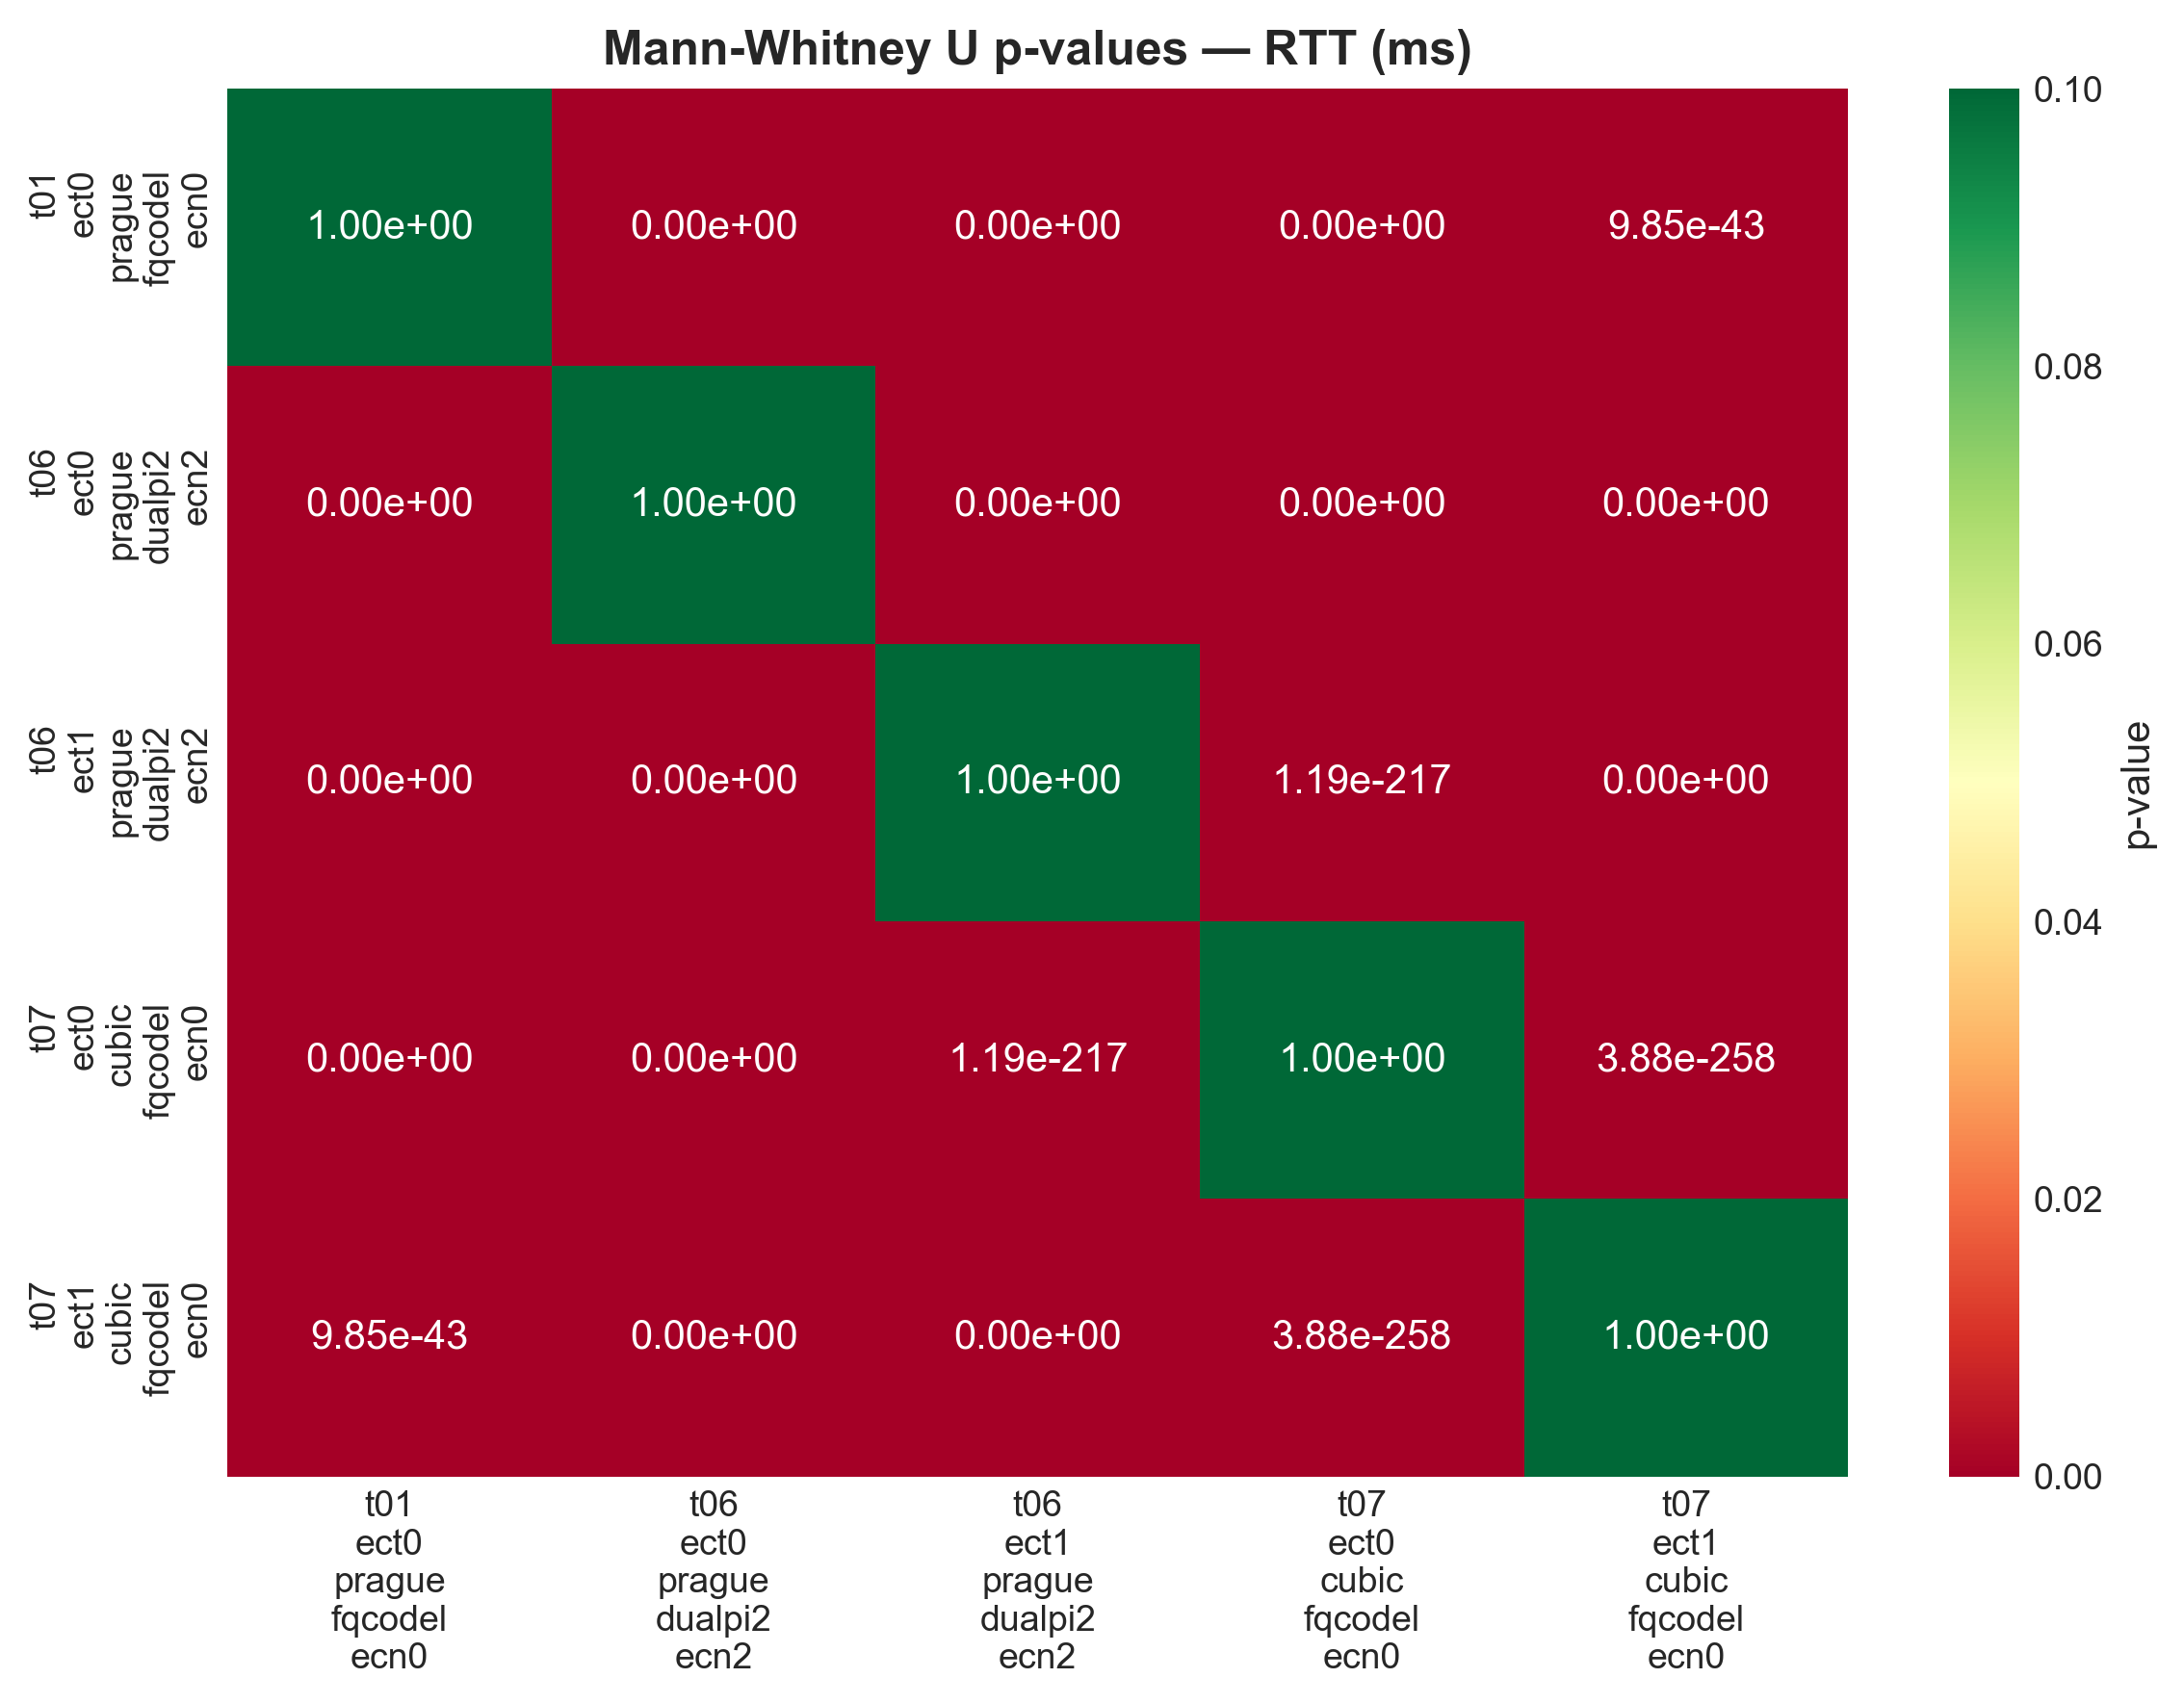

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/cross_scenario_mwu_jitter_ms.png


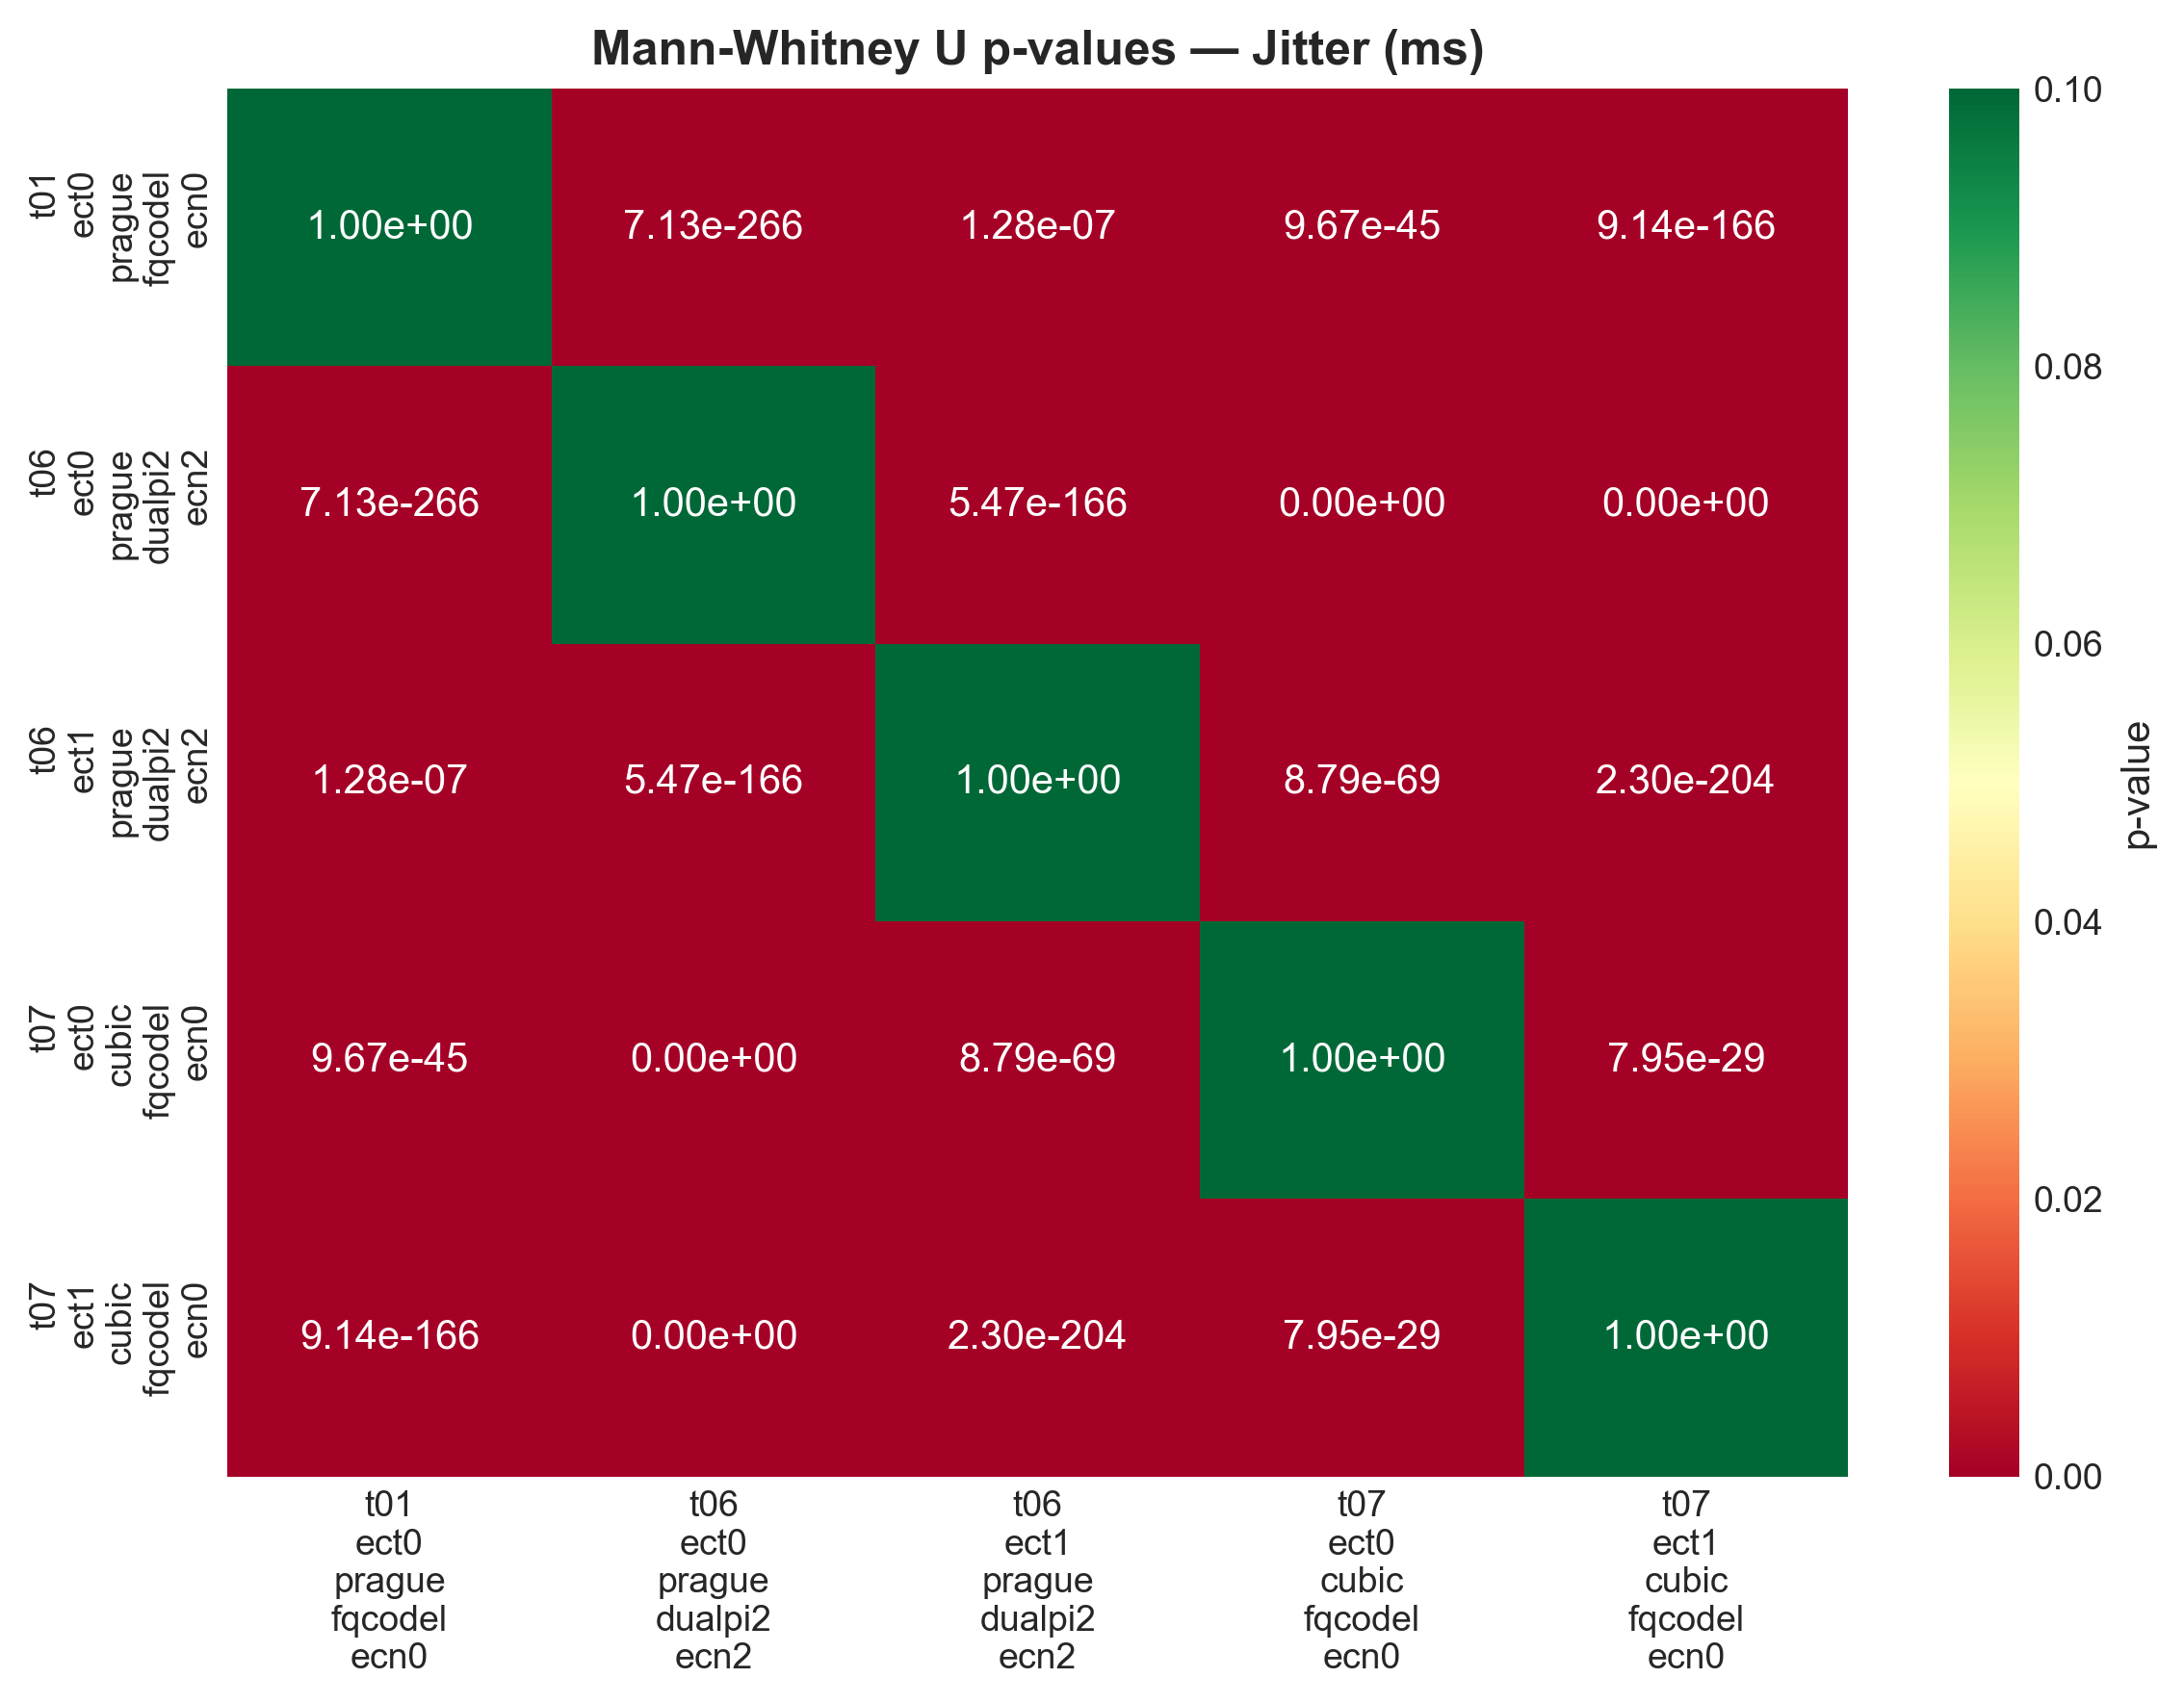

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/cross_scenario_mwu_pacing_rate_mbps.png


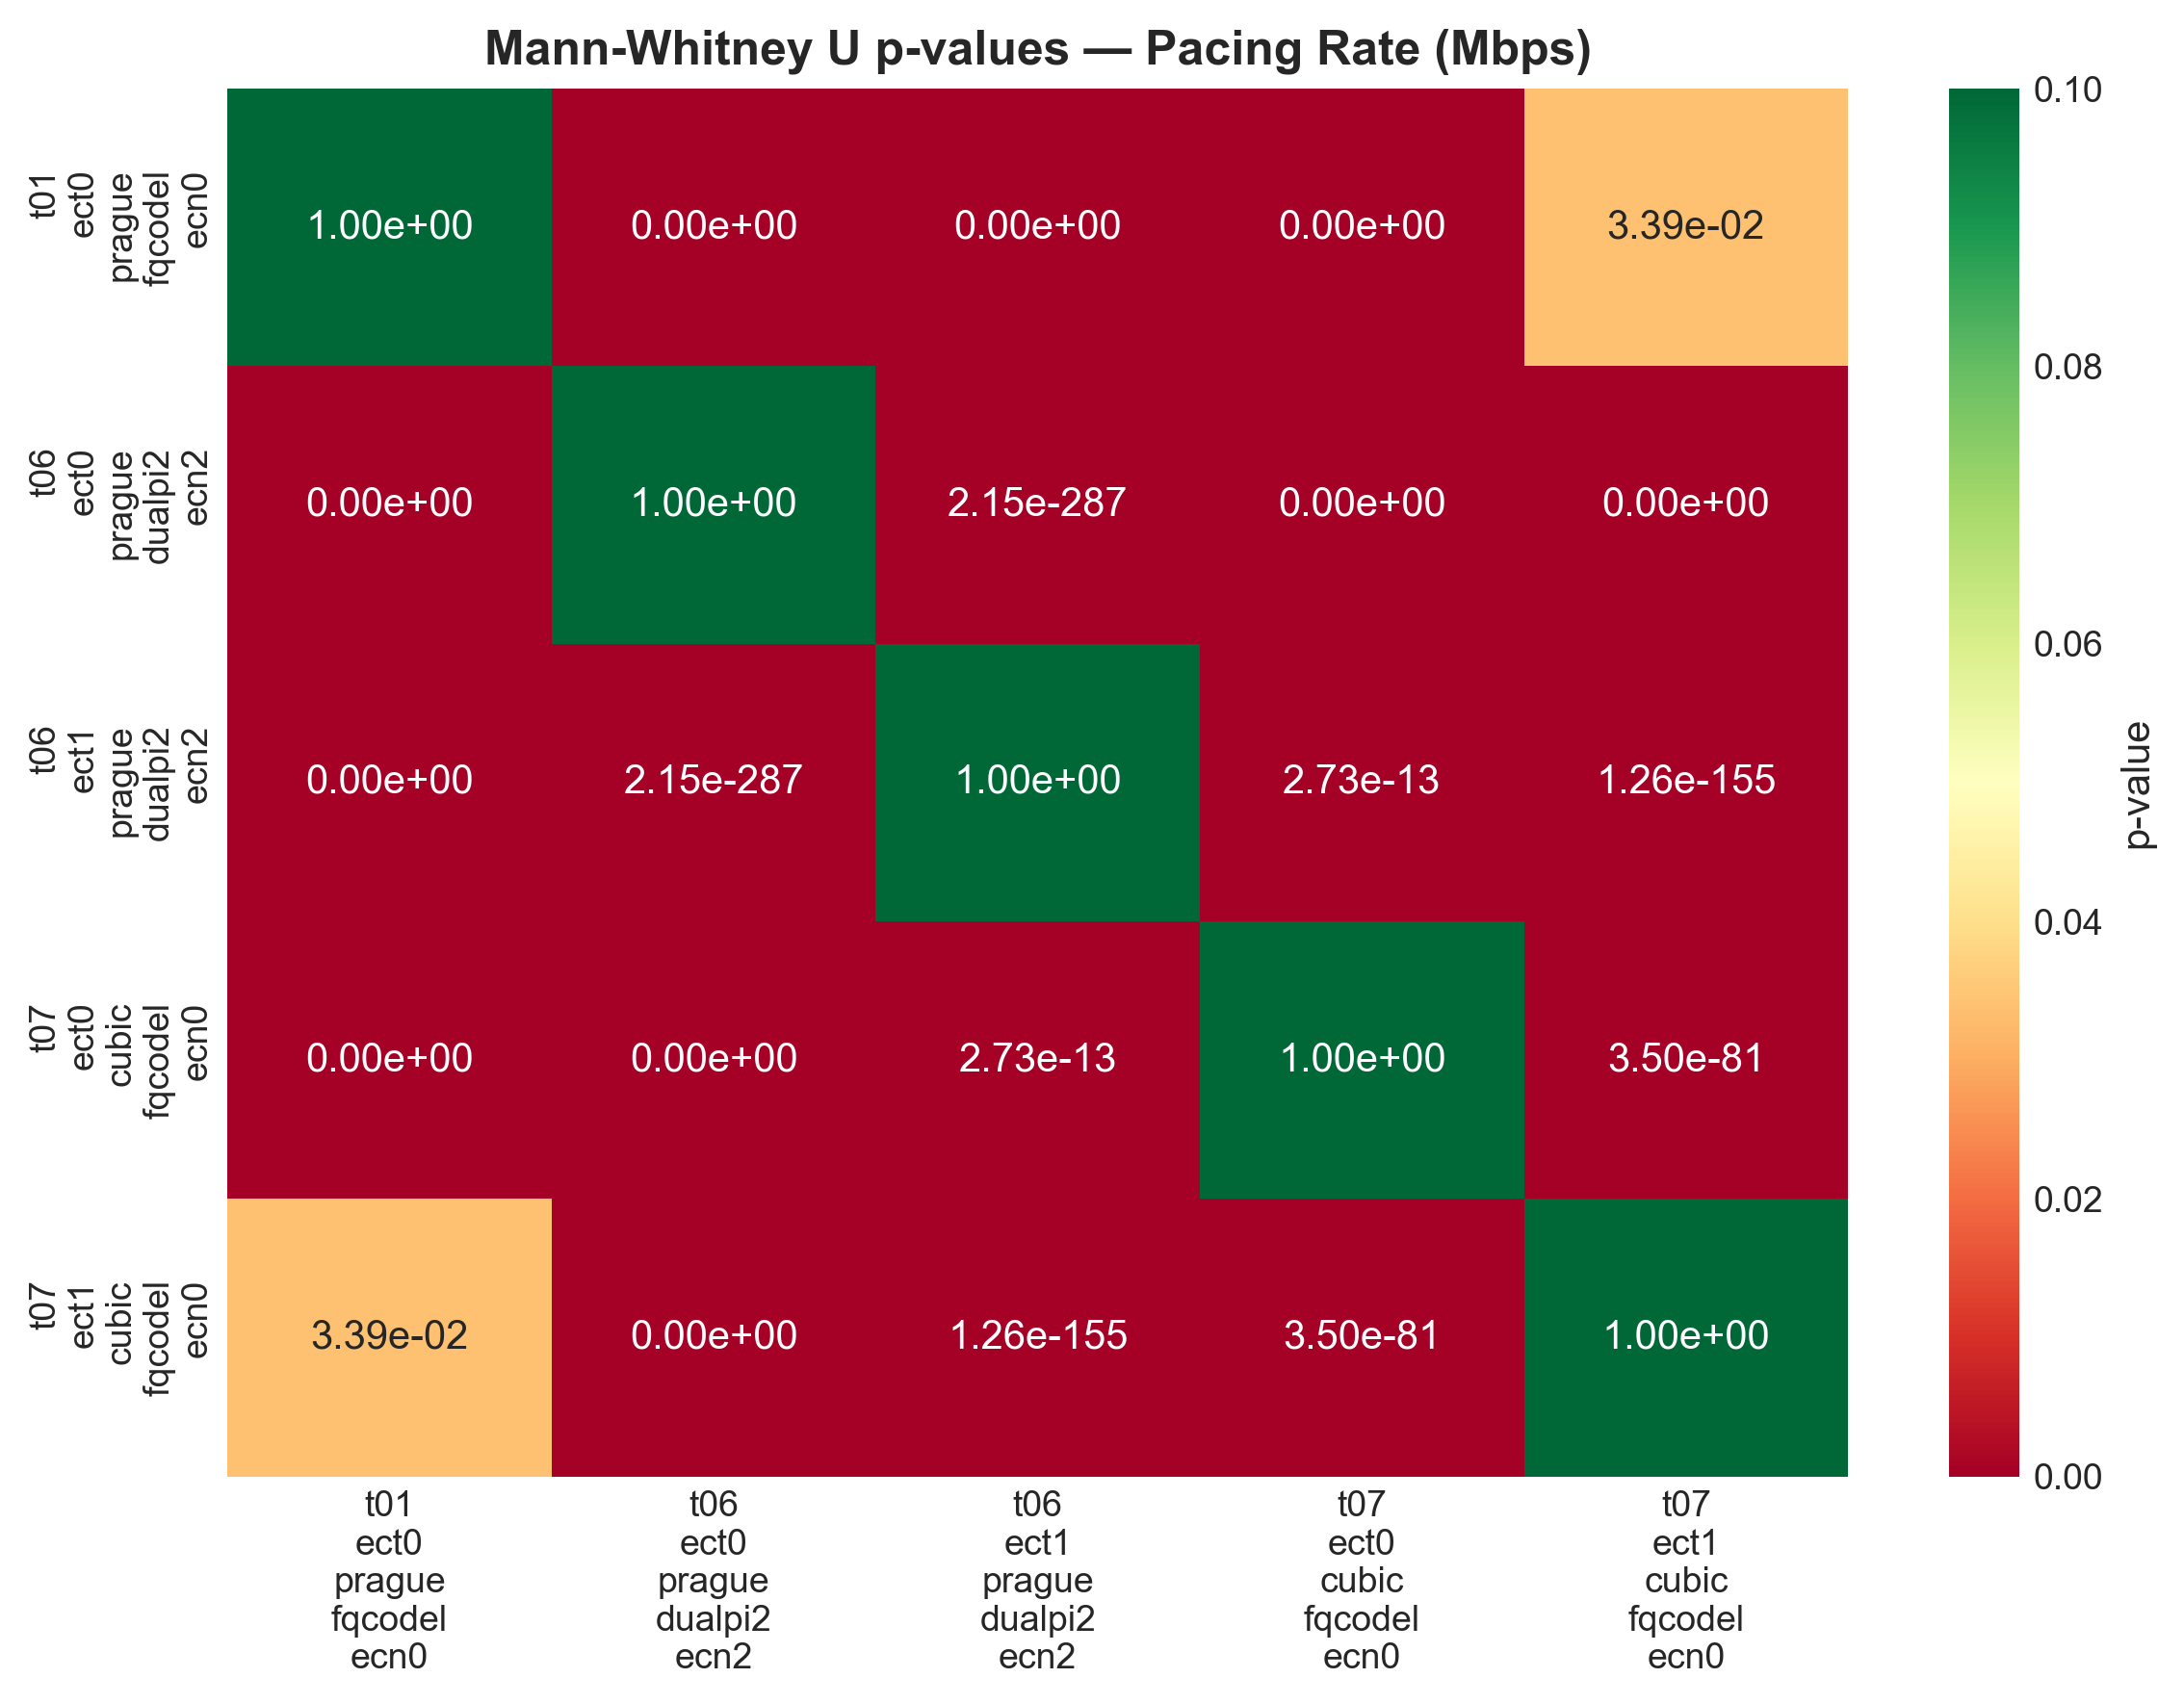

In [181]:
# ===== CROSS-SCENARIO HYPOTHESIS TESTING (Mann-Whitney U) =====
# Compares key metrics across all available experiment scenarios.
# Requirements: at least 2 scenarios with _client.csv data.

from scipy.stats import mannwhitneyu
from itertools import combinations

WARMUP_FRAC = 0.10  # exclude first 10% (warmup)
EXPERIMENTS_DIR = ROOT / 'experiments'

def load_scenario_data(experiment_dir):
    """Load client CSV data for a scenario, applying steady-state segmentation.
    Supports multiple runs: concatenates all esp_client_N.log / *_client.csv files.
    """
    # Try CSV files first (from batch processing)
    csv_files = sorted(experiment_dir.glob('*_client.csv'))
    csv_files = [f for f in csv_files if not f.name.startswith('old_')]
    if not csv_files:
        return None
    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        if not df.empty:
            dfs.append(df)
    if not dfs:
        return None
    df = pd.concat(dfs, ignore_index=True)
    if len(df) < 50:
        return None
    # Steady-state segmentation
    n_warmup = int(len(df) * WARMUP_FRAC)
    return df.iloc[n_warmup:].copy()

def scenario_label(dirname):
    """Extract short label from directory name (e.g., t06-ect1-prague-dualpi2-ecn2)."""
    parts = dirname.split('-')
    if len(parts) >= 6:
        # t06-ecn-sender-ect1-prague-dualpi2-ecn2 -> t06/ect1/prague/dualpi2/ecn2
        return f"{parts[0]}/{parts[3]}/{parts[4]}/{parts[5]}/{parts[6]}"
    return dirname

# --- Load all available scenarios ---
scenarios = {}
for exp_dir in sorted(EXPERIMENTS_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue
    df = load_scenario_data(exp_dir)
    if df is not None:
        label = scenario_label(exp_dir.name)
        scenarios[label] = df

print(f"Scenarios with data: {len(scenarios)}")
for label, df in scenarios.items():
    print(f"  {label}: {len(df):,} steady-state samples")

METRICS_TO_TEST = {
    'RTT (ms)': 'rtt_ms',
    'Jitter (ms)': 'jitter_ms',
    'Pacing Rate (Mbps)': 'pacing_rate_mbps',
}

if len(scenarios) >= 2:
    print("\n" + "="*80)
    print("MANN-WHITNEY U TEST — PAIRWISE CROSS-SCENARIO COMPARISON")
    print("="*80)
    print("H0: The two samples come from the same distribution.")
    print("Significance level: α = 0.05")

    labels = list(scenarios.keys())
    all_results = []

    for metric_name, col in METRICS_TO_TEST.items():
        print(f"\n--- {metric_name} ---")
        print(f"{'Scenario A':<35} {'Scenario B':<35} {'U-stat':>12} {'p-value':>12} {'Result':>12}")
        print("-" * 108)

        for a, b in combinations(labels, 2):
            data_a = scenarios[a][col].dropna().values
            data_b = scenarios[b][col].dropna().values

            if len(data_a) < 20 or len(data_b) < 20:
                print(f"{a:<35} {b:<35} {'N/A':>12} {'N/A':>12} {'skip (n<20)':>12}")
                continue

            u_stat, p_val = mannwhitneyu(data_a, data_b, alternative='two-sided')
            sig = 'REJECT H0 *' if p_val < 0.05 else 'FAIL TO REJ'

            print(f"{a:<35} {b:<35} {u_stat:>12.1f} {p_val:>12.2e} {sig:>12}")

            all_results.append({
                'metric': metric_name,
                'scenario_a': a,
                'scenario_b': b,
                'mean_a': np.mean(data_a),
                'mean_b': np.mean(data_b),
                'u_statistic': u_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
            })

    # --- Export results ---
    if all_results:
        df_mwu = pd.DataFrame(all_results)
        mwu_path = EXPERIMENTS_DIR / 'cross_scenario_mannwhitney.csv'
        df_mwu.to_csv(mwu_path, index=False)
        print(f"\n✓ Saved: {mwu_path}")

    # --- Heatmap (if ≥3 scenarios) ---
    if len(scenarios) >= 3:
        for metric_name, col in METRICS_TO_TEST.items():
            n = len(labels)
            pval_matrix = np.ones((n, n))

            for i, j in combinations(range(n), 2):
                data_i = scenarios[labels[i]][col].dropna().values
                data_j = scenarios[labels[j]][col].dropna().values
                if len(data_i) >= 20 and len(data_j) >= 20:
                    _, p = mannwhitneyu(data_i, data_j, alternative='two-sided')
                    pval_matrix[i, j] = p
                    pval_matrix[j, i] = p

            fig, ax = plt.subplots(figsize=(max(8, n * 1.5), max(6, n * 1.2)))
            short_labels = [l.replace('/', '\n') for l in labels]
            sns.heatmap(pval_matrix, xticklabels=short_labels, yticklabels=short_labels,
                        annot=True, fmt='.2e', cmap='RdYlGn', vmin=0, vmax=0.1,
                        cbar_kws={'label': 'p-value'}, ax=ax)
            ax.set_title(f'Mann-Whitney U p-values — {metric_name}', fontsize=12, fontweight='bold')
            plt.tight_layout()
            safe_name = metric_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
            fname = EXPERIMENTS_DIR / f'cross_scenario_mwu_{safe_name}.png'
            fig.savefig(fname, dpi=300, bbox_inches='tight')
            print(f"✓ Saved: {fname}")
            plt.show()

elif len(scenarios) == 1:
    print("\n⚠️  Only 1 scenario with data — Mann-Whitney U requires at least 2 scenarios.")
    print("   Run more experiments to enable cross-scenario statistical comparison.")
else:
    print("\n⚠️  No scenario data found for hypothesis testing.")